In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import imprl.envs

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.25,
    font="Times New Roman",
)

# Excess cost relative to SARSOP, by cost component

For each k-out-of-4 system, the best policy's cost (across 10 seeds) minus SARSOP's, split into its four cost terms and expressed as a % of SARSOP's total cost. It looks at
- which cost terms each policy over-spends on (positive segments) or saves on (negative segments) vs. SARSOP
- the net excess cost — black diamonds, annotated above each bar
- the absence of a single cost term driving the excess across settings or algorithms

Mapping components to failure modes: replacement / mobilization → over-repair, inspection → misaligned inspection cycles, risk → failures from ignored component dependencies.

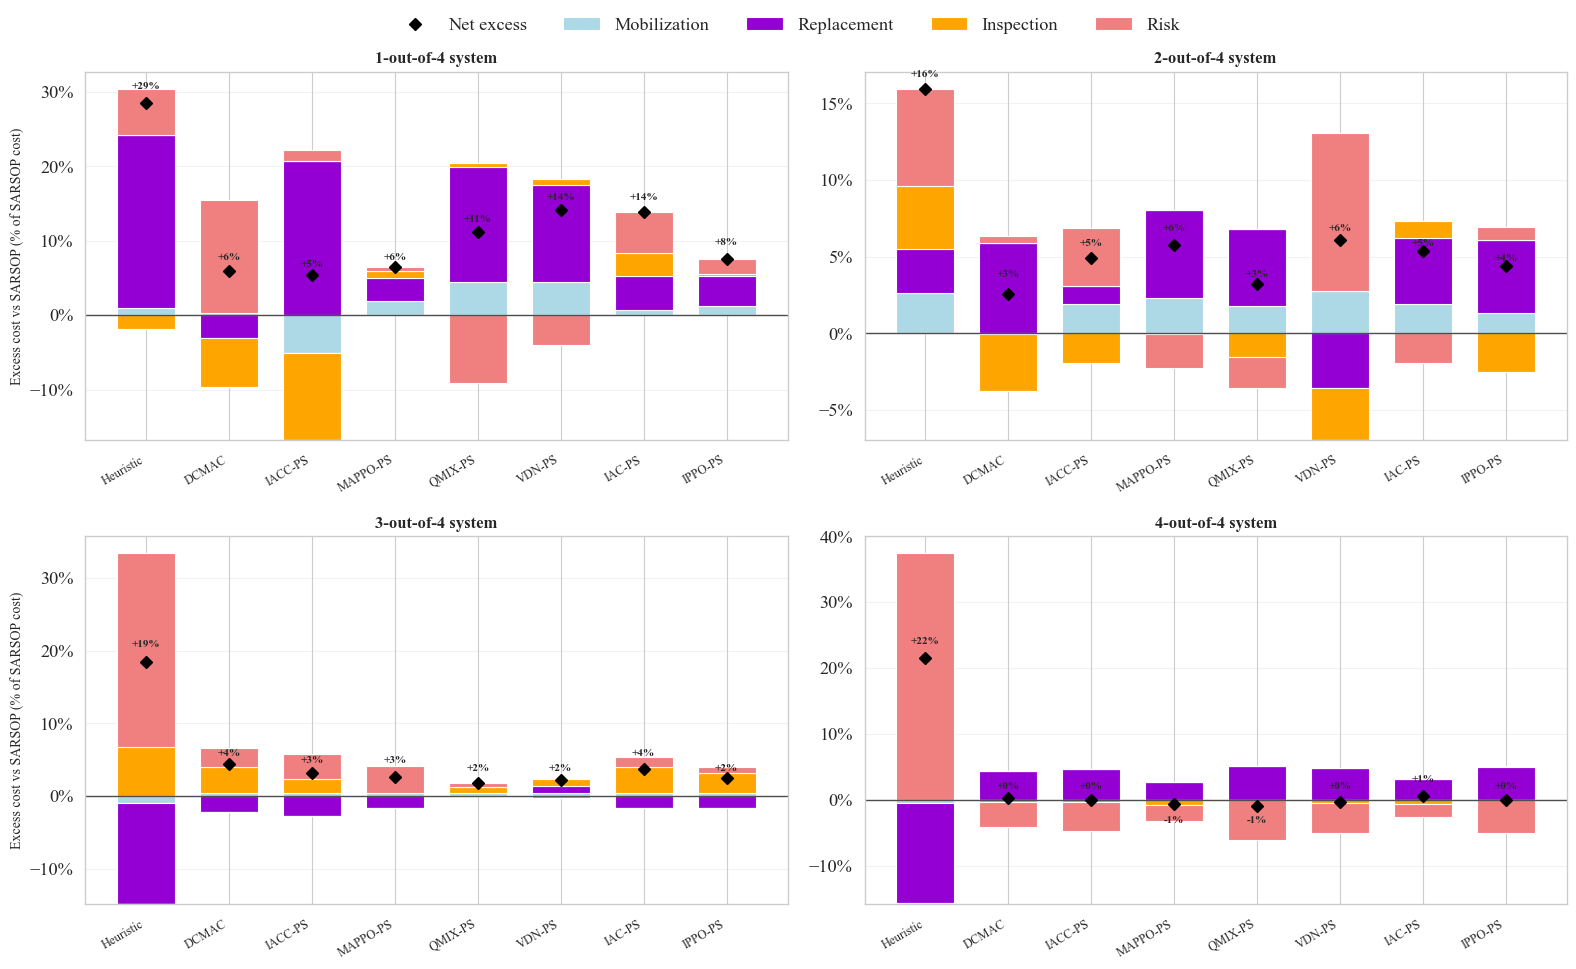

In [ ]:
import pickle
from pathlib import Path
from matplotlib.ticker import PercentFormatter

ROLLOUT_ROOT = Path("./data/rollout_data/k_out_of_n_infinite")
OPTIMAL = "SARSOP"
# k-out-of-4 settings, ordered from most redundant (parallel) to least (series).
EXCESS_SETTINGS = [f"hard-{k}-of-4_infinite" for k in range(1, 5)]
ALG_NAMES = {
    "DCMAC": "DCMAC",
    "IACC_PS": "IACC-PS",
    "MAPPO_PS": "MAPPO-PS",
    "QMIX_PS": "QMIX-PS",
    "VDN_PS": "VDN-PS",
    "IAC_PS": "IAC-PS",
    "IPPO_PS": "IPPO-PS",
}

COST_COMPONENTS = ["mobilisation", "replacement", "inspection", "risk"]
COST_LABELS = ["Mobilization", "Replacement", "Inspection", "Risk"]
COST_COLORS = ["lightblue", "darkviolet", "orange", "lightcoral"]
EXCESS_ALGS = ["InspectRepair", "DCMAC", "IACC_PS", "MAPPO_PS", "QMIX_PS", "VDN_PS", "IAC_PS", "IPPO_PS"]
EXCESS_NAMES = {"InspectRepair": "Heuristic", **ALG_NAMES}


def mean_cost_components(setting, alg):
    """Mean per-episode cost of each component (positive magnitudes) for one (setting, algorithm)."""
    path = ROLLOUT_ROOT / setting / alg / "rollout_data_costs.pkl"
    if not path.exists():
        path = ROLLOUT_ROOT / setting / alg / "rollout_data.pkl"
    with open(path, "rb") as f:
        episodes = list(pickle.load(f).values())
    return {
        c: abs(np.mean([np.sum(ep[f"cost_{c}"]) for ep in episodes]))
        for c in ["mobilisation", "risk", "inspections", "replacements"]
    }


def excess_vs_sarsop(setting):
    """Per-component excess cost over SARSOP, as % of SARSOP's total cost."""
    rename = {"inspections": "inspection", "replacements": "replacement"}
    costs = pd.DataFrame(
        {a: mean_cost_components(setting, a) for a in [OPTIMAL] + EXCESS_ALGS}
    ).T.rename(columns=rename)[COST_COMPONENTS]
    sarsop = costs.loc[OPTIMAL]
    return (costs.drop(index=OPTIMAL) - sarsop) / sarsop.sum() * 100



fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()
x = np.arange(len(EXCESS_ALGS))

for ax_idx, (ax, s) in enumerate(zip(axes, EXCESS_SETTINGS)):
    deltas = excess_vs_sarsop(s)

    # Stack positive and negative contributions from a shared zero baseline.
    pos_bottom, neg_bottom = np.zeros(len(x)), np.zeros(len(x))
    for comp, label, color in zip(COST_COMPONENTS, COST_LABELS, COST_COLORS):
        vals = deltas[comp].values
        pos, neg = np.clip(vals, 0, None), np.clip(vals, None, 0)
        ax.bar(x, pos, bottom=pos_bottom, width=0.7, color=color,
               label=label if ax_idx == 0 else "")
        ax.bar(x, neg, bottom=neg_bottom, width=0.7, color=color)
        pos_bottom += pos
        neg_bottom += neg

    net = deltas.sum(axis=1).values  # net excess (% of SARSOP cost)
    ax.plot(x, net, "D", color="black", markersize=6, zorder=5,
            label="Net excess" if ax_idx == 0 else "")
    for xi, n in zip(x, net):
        n = round(n) + 0.0  # avoid "-0%"
        ax.annotate(f"{n:+.0f}%", (xi, n), textcoords="offset points",
                    xytext=(0, 8 if n >= 0 else -12), ha="center",
                    fontsize=8, fontweight="bold")

    ax.axhline(0, color="0.3", linewidth=1)
    ax.set_title(f"{s.split('-')[1]}-out-of-4 system",
                 fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([EXCESS_NAMES[a] for a in EXCESS_ALGS], rotation=30,
                       ha="right", fontsize=9, fontweight="medium")
    ax.tick_params(axis="x", pad=5)
    ax.grid(axis="y", alpha=0.25)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    if ax_idx % 2 == 0:
        ax.set_ylabel("Excess cost vs SARSOP (% of SARSOP cost)", fontsize=10)

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="upper center", ncol=5,
           bbox_to_anchor=(0.5, 0.98), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_name = "excess_cost_vs_sarsop"
plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)
plt.show()

# Combined Plots

In [2]:
from matplotlib.ticker import PercentFormatter

def get_box_plot(ax, num_comps=3):
    """
    Draw grouped box + strip plots of normalized_best_cost
    for k-out-of-n settings (n = 2, 3, or 4) on a given axes.

    Uses the global `results_summary_df` (one row per run).
    Returns (handles, labels) for the legend when num_comps == 4,
    else returns (None, None).
    """
    # Use the global summary dataframe
    results_summary_df = pd.read_csv("./data/results_summary.csv")

    # -------------------------- Configuration --------------------------
    ENV_NAME = "k_out_of_n_infinite"

    ALGORITHM_META = {
        "DDQN": {"paradigm": "CTCE (POMDP)", "name": "DDQN"},
        "JAC": {"paradigm": "CTCE (POMDP)", "name": "JAC"},
        "DCMAC": {"paradigm": "CTCE (MPOMDP)", "name": "DCMAC"},
        "IACC_PS": {"paradigm": "CTDE (Dec-POMDP)", "name": "IACC-PS"},
        "MAPPO_PS": {"paradigm": "CTDE (Dec-POMDP)", "name": "MAPPO-PS"},
        "QMIX_PS": {"paradigm": "CTDE (Dec-POMDP)", "name": "QMIX-PS"},
        "VDN_PS": {"paradigm": "CTDE (Dec-POMDP)", "name": "VDN-PS"},
        "IAC_PS": {"paradigm": "DTDE (Dec-POMDP)", "name": "IAC-PS"},
        "IPPO_PS": {"paradigm": "DTDE (Dec-POMDP)", "name": "IPPO-PS"},
    }
    ALGORITHMS = list(ALGORITHM_META.keys())
    ALGORITHM_NAMES = [ALGORITHM_META[a]["name"] for a in ALGORITHMS]

    # Pick settings, titles, and x-limits per n
    if num_comps == 4:
        SETTINGS = [f"n4_k{k}_nomob_fpf1.5" for k in range(1, 5)]
        SETTINGS_TITLES = [
            "1-out-of-4 system\n (parallel configuration)",
            "2-out-of-4 system\n ",
            "3-out-of-4 system\n ",
            "4-out-of-4 system\n (series configuration)",
        ]
        X_LIMIT = (-0.5, 3.5)

    elif num_comps == 3:
        SETTINGS = [f"n3_k{k}_nomob" for k in range(1, 4)]
        SETTINGS_TITLES = [
            "1-out-of-3 system\n (parallel configuration)",
            "2-out-of-3 system\n ",
            "3-out-of-3 system\n (series configuration)",
        ]
        X_LIMIT = (-0.5, 2.5)

    elif num_comps == 2:
        SETTINGS = [f"n2_k{k}_nomob" for k in range(1, 3)]
        SETTINGS_TITLES = [
            "1-out-of-2 system\n (parallel configuration)",
            "2-out-of-2 system\n (series configuration)",
        ]
        X_LIMIT = (-0.5, 1.5)

    else:
        raise ValueError("num_comps must be 2, 3, or 4.")

    # ------------------- Slice and order the results -------------------
    df = results_summary_df[
        results_summary_df["setting"].isin(SETTINGS)
        & results_summary_df["algorithm"].isin(ALGORITHMS)
    ].copy()

    # Enforce plotting order
    df["setting"] = pd.Categorical(df["setting"], categories=SETTINGS, ordered=False)
    df["algorithm"] = pd.Categorical(
        df["algorithm"], categories=ALGORITHMS, ordered=False
    )
    df = df.sort_values(["algorithm", "setting"])

    # Baselines from the environments (for SARSOP + heuristic bands)
    BASELINES = {}
    for setting in SETTINGS:
        env = imprl.envs.make(ENV_NAME, setting)
        BASELINES[setting] = env.core.baselines

    RANDOM_SEEDS = 10
    # assert that there are RANDOM_SEEDS unique run ids per algorithm-setting pair
    for alg in ALGORITHMS:
        for setting in SETTINGS:
            # Results summary
            subset = df[(df["algorithm"] == alg) & (df["setting"] == setting)]
            unique_run_ids = subset["run_id"].nunique()
            assert (
                unique_run_ids == RANDOM_SEEDS
            ), f"Algorithm {alg} in setting {setting} has {unique_run_ids} unique run ids, expected {RANDOM_SEEDS}"

    # ---------------------------- Plotting ----------------------------
    # Derive paradigm ordering and colors from ALGORITHM_META
    from itertools import groupby, cycle

    PARADIGMS = [ALGORITHM_META[a]["paradigm"] for a in ALGORITHMS]
    PARADIGM_ORDER = list(dict.fromkeys(PARADIGMS))
    PARADIGM_RUNS = [(p, sum(1 for _ in g)) for p, g in groupby(PARADIGMS)]

    _default_paradigm_colors = {
        "CTCE (POMDP)": "tab:green",
        "CTCE (MPOMDP)": "tab:cyan",
        "CTDE (Dec-POMDP)": "tab:blue",
        "DTDE (Dec-POMDP)": "tab:red",
    }
    PARADIGM_COLORS = {p: _default_paradigm_colors.get(p) for p in PARADIGM_ORDER}
    _color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])
    for p in PARADIGM_ORDER:
        if PARADIGM_COLORS[p] is None:
            PARADIGM_COLORS[p] = next(_color_cycle)

    # Shaded bands for MADRL paradigms along x
    _patch_alpha, ymin, ymax = 0.1, 0.16, 1.0
    for s_idx in range(len(SETTINGS)):
        left = -0.4 + s_idx
        per_alg_width = 0.8 / len(ALGORITHMS)
        for paradigm, count in PARADIGM_RUNS:
            right = left + count * per_alg_width
            ax.axvspan(
                left,
                right,
                ymin,
                ymax,
                facecolor=PARADIGM_COLORS[paradigm],
                alpha=_patch_alpha,
            )
            left = right

    # Box + strip plots over normalized_best_cost (already normalized in CSV)
    sns.boxplot(
        data=df,
        ax=ax,
        x="setting",
        y="normalized_best_cost",
        hue="algorithm",
        hue_order=ALGORITHMS,
        palette="tab10",
        showmeans=True,
        linewidth=1,
        gap=0.1,
        zorder=0,
        legend=False,
        boxprops=dict(alpha=0.9),
    )
    sns.stripplot(
        data=df,
        ax=ax,
        x="setting",
        y="normalized_best_cost",
        hue="algorithm",
        hue_order=ALGORITHMS,
        palette="tab10",
        dodge=True,
        alpha=0.3,
        jitter=0.1,
        zorder=2,
        legend=False,
    )

    # ----------- Replace x-ticks by algorithm names ------------
    all_patches = [p for p in ax.patches if isinstance(p, matplotlib.patches.PathPatch)]

    positions = []
    for patch in all_patches:
        verts = patch.get_path().vertices
        box_x = verts[0:2, 0].mean()
        positions.append(box_x)
    positions = sorted(positions)

    labels = ALGORITHM_NAMES * len(SETTINGS)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=90, ha="left")
    ax.set_xlabel(None)

    # -------------------- Heuristics and baselines --------------------
    # SARSOP baseline line at zero (normalized)
    ax.axhline(y=0.0, color="r", linestyle="-", label=r"SARSOP MC mean ($C^*$)")

    for s_idx, setting in enumerate(SETTINGS):
        sarsop = BASELINES[setting]["SARSOP"]
        mean_sarsop = sarsop["mean"]
        LBound, UBound = sarsop["LBound"], sarsop["UBound"]

        # LBound–UBound band (normalized by SARSOP mean)
        rel_L = LBound / mean_sarsop - 1
        rel_U = UBound / mean_sarsop - 1
        ax.fill_between(
            [s_idx - 0.4, s_idx + 0.4],
            rel_L,
            rel_U,
            color="orange",
            alpha=0.1,
            edgecolor="black",
            label="SARSOP (LBound, UBound)",
        )

        # Monte Carlo 95% CI around SARSOP (normalized)
        MC_mean, MC_95_ci = sarsop["mean"], sarsop["95_ci"]
        MC_lower = MC_95_ci[0] / MC_mean - 1
        MC_upper = MC_95_ci[1] / MC_mean - 1
        ax.fill_between(
            [s_idx - 0.45, s_idx + 0.45],
            MC_lower,
            MC_upper,
            color=None,
            alpha=0.1,
            edgecolor="black",
            hatch="///",
            linewidth=1,
            # label="SARSOP 95% CI",
        )

        # Heuristic: Inspect–repair (normalized by SARSOP mean)
        heur = BASELINES[setting]["InspectRepair"]
        H_mean, H_95_ci = heur["mean"], heur["95_ci"]
        H_lower = H_95_ci[0] / MC_mean - 1
        H_upper = H_95_ci[1] / MC_mean - 1

        ax.hlines(
            y=H_mean / MC_mean - 1,
            xmin=s_idx - 0.45,
            xmax=s_idx + 0.45,
            color="black",
            linestyle="--",
            linewidth=1.5,
            alpha=0.5,
            label="Heuristic mean",
        )
        ax.fill_between(
            [s_idx - 0.45, s_idx + 0.45],
            H_lower,
            H_upper,
            color=None,
            alpha=0.1,
            edgecolor="blue",
            hatch="///",
            linewidth=1,
            label="95% CI",
        )

    # Secondary top x-axis with k-out-of-n titles
    secax = ax.secondary_xaxis("top")
    secax.set_xticks(np.arange(len(SETTINGS)))
    secax.set_xticklabels(SETTINGS_TITLES, fontsize=14, fontdict={"weight": "bold"})
    secax.tick_params(axis="x", which="both", length=0)

    # Axes limits and labels
    ax.set_xlim(*X_LIMIT)
    ax.set_ylim(-0.1, 0.4)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

    # Indicate distributions extending beyond the top y-limit.
    y_top = ax.get_ylim()[1]
    num_algs = len(ALGORITHMS)
    max_by_pair = df.groupby(["setting", "algorithm"], observed=False)[
        "normalized_best_cost"
    ].max()
    for s_idx, setting in enumerate(SETTINGS):
        for a_idx, alg in enumerate(ALGORITHMS):
            max_val = max_by_pair.get((setting, alg), np.nan)
            if pd.notna(max_val) and max_val > y_top:
                x_idx = s_idx * num_algs + a_idx
                if x_idx < len(positions):
                    x_pos = positions[x_idx]
                    ax.annotate(
                        "",
                        xy=(x_pos, y_top + 0.005),
                        xytext=(x_pos, y_top - 0.035),
                        arrowprops=dict(arrowstyle="->", color="blue", lw=1.5, alpha=0.8),
                        clip_on=False,
                        annotation_clip=False,
                        zorder=5,
                    )

    ax.set_ylabel(r"optimality gap $\left( \Delta = \frac{C - C^*}{C^*} \times 100\% \right)$", fontsize=12)

    # --- Redundancay arrow below ---
    _top_arrow_y = -0.06
    ax.text(
        len(SETTINGS) / 2 - 0.5,
        _top_arrow_y,
        "increasing redundancy",
        fontsize=12,
        ha="center",
        va="bottom",
    )
    ax.annotate(
        "",
        xy=(0.02, _top_arrow_y),
        xytext=(len(SETTINGS) - 1, _top_arrow_y),
        arrowprops=dict(arrowstyle="-|>", color="blue", lw=1.5, alpha=0.8),
    )

    #  ----------------------- Environment info  -----------------------
    env = imprl.envs.make(ENV_NAME, setting=SETTINGS[0])
    fpf = env.core.FAILURE_PENALTY_FACTOR
    mob_cost = env.core.mobilisation_reward
    env_info_text = (
        rf"Failure penalty factor ($\kappa$) = {fpf}"
        + "\n"
        + rf"Mobilization cost ($c_{{\mathrm{{mob}}}}$) = {mob_cost}"
    )
    ax.text(
        0.55,
        0.86,
        env_info_text,
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=12,
        alpha=0.5,
        fontweight="bold",
        color="blue",
    )

    # -------------------- Legend (only build for num_comps=4) --------------------
    if num_comps == 4:
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch

        auto_handles, auto_labels = ax.get_legend_handles_labels()

        # Marker used by seaborn for means
        mean_marker = Line2D(
            [0],
            [0],
            color="tab:green",
            marker="^",
            linestyle="None",
            markersize=5,
            label="mean",
        )

        paradigm_handles = [
            Patch(color=PARADIGM_COLORS[p], alpha=_patch_alpha, label=p)
            for p in PARADIGM_ORDER
        ]

        base_handles = paradigm_handles

        all_handles = base_handles + list(auto_handles) + [mean_marker]
        all_labels = [h.get_label() for h in all_handles]

        # Remove duplicates while preserving order
        unique = {}
        for lbl, h in zip(all_labels, all_handles):
            if lbl and lbl not in unique:
                unique[lbl] = h

        return list(unique.values()), list(unique.keys())

    return None, None

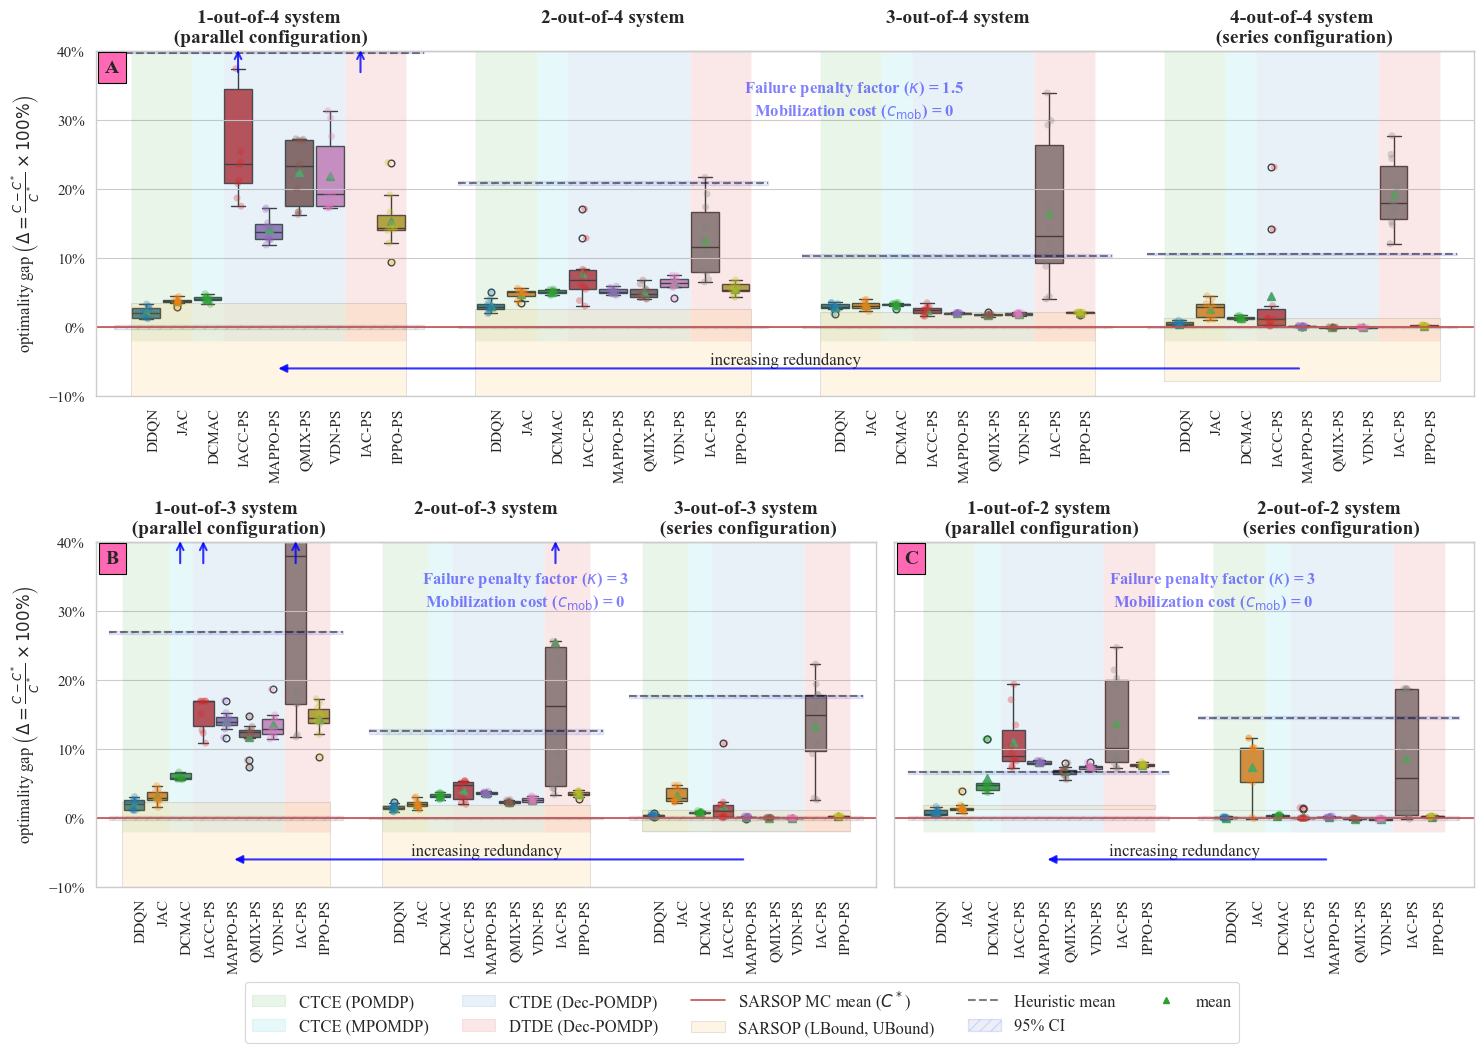

In [3]:
# Combined mosaic figure: A = n=4, B = n=3, C = n=2
fig = plt.figure(figsize=(15, 10))

mosaic = """
AAAAAAA
BBBBCCC
"""
axes = fig.subplot_mosaic(mosaic, height_ratios=[1, 1], sharey=True)
axA, axB, axC = axes["A"], axes["B"], axes["C"]

# --- Panel plots ---
handles, labels = get_box_plot(axA, num_comps=4)  # returns legend only for n=4
get_box_plot(axB, num_comps=3)
get_box_plot(axC, num_comps=2)

# --- Panel labels in upper-left corners ---
for ax, label, x in [(axA, "A", 0.006), (axB, "B", 0.012), (axC, "C", 0.018)]:
    ax.text(
        x,
        0.975,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(facecolor="hotpink", alpha=1, edgecolor="black", pad=5),
    )

# --- Global legend from panel A (n=4) ---
if handles is not None and labels is not None:
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=5,
        bbox_to_anchor=(0.5, -0.06),
        fontsize=12,
        frameon=True,
    )

fig.tight_layout()

fig_name = "combined_boxplot_ablations"
plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)

plt.show()

# n4_nomob_fpf1.5

In [7]:
# Load data
results_summary_df = pd.read_csv("./data/results_summary.csv")
results_evals_df = pd.read_csv("./data/results_evals.csv")

ENV_NAME = "k_out_of_n_infinite"
SETTINGS = [f"n4_k{k}_nomob_fpf1.5" for k in range(1, 5)]
SETTING_NAMES = [f"n4_k{k}_nomob_fpf1.5" for k in range(1, 5)]

ALGORITHMS = results_summary_df["algorithm"].unique().tolist()
ALGORITHM_NAMES = [alg.replace("_", "-").upper() for alg in ALGORITHMS]
RANDOM_SEEDS = 10

BASELINES = {}
for setting in SETTINGS:
    env = imprl.envs.make(ENV_NAME, setting)
    BASELINES[setting] = env.core.baselines

### Box Plots

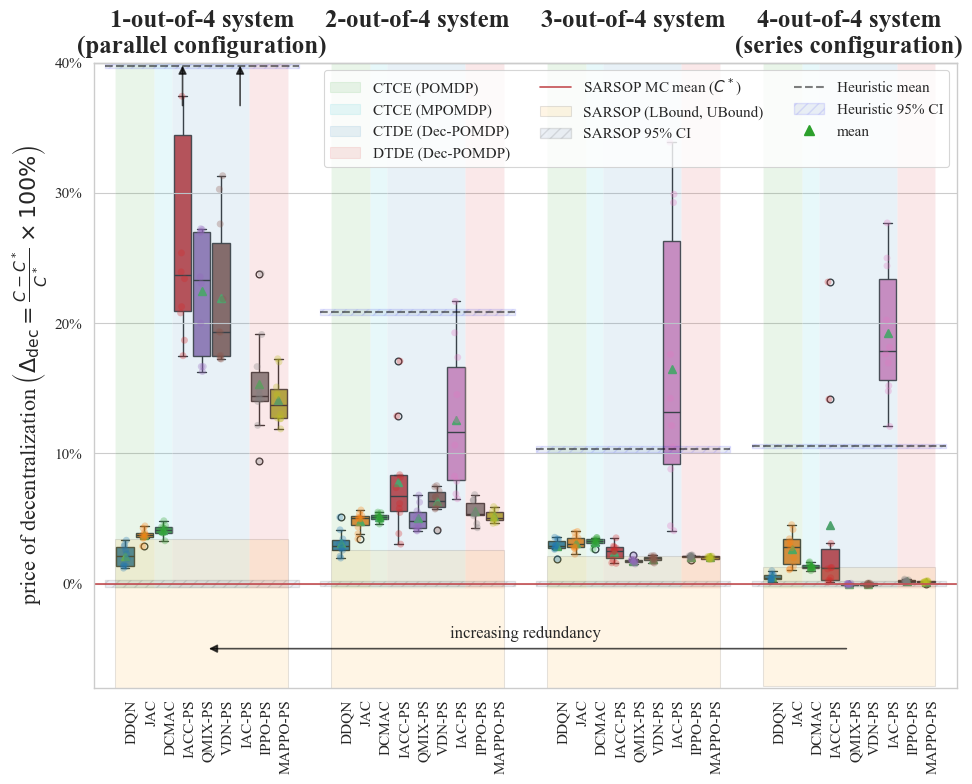

In [8]:
from matplotlib.ticker import PercentFormatter

# Subset data
results_subset_df = results_summary_df[
    results_summary_df["algorithm"].isin(ALGORITHMS)
    & results_summary_df["setting"].isin(SETTINGS)
].copy()

# Grouped box + strip plot per setting, with baseline bands and config shading
fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(axis="x", linestyle="-", alpha=0.01)

_patch_alpha = 0.1
ymin, ymax = 0.16, 1.0

# --- Shade CTCE / CTDE / DTDE regions per setting on the x axis ---
for s in range(len(SETTINGS)):
    ax.axvspan(
        -0.4 + s, -0.22 + s, ymin, ymax, facecolor="tab:green", alpha=_patch_alpha
    )  # CTCE (POMDP)
    ax.axvspan(
        -0.22 + s, -0.14 + s, ymin, ymax, facecolor="tab:cyan", alpha=_patch_alpha
    )  # CTCE (MPOMDP)
    ax.axvspan(
        -0.14 + s, 0.22 + s, ymin, ymax, facecolor="tab:blue", alpha=_patch_alpha
    )  # CTDE (Dec-POMDP)
    ax.axvspan(
        0.22 + s, 0.40 + s, ymin, ymax, facecolor="tab:red", alpha=_patch_alpha
    )  # DTDE (Dec-POMDP)

# --- Boxplot + stripplot per setting and algorithm ---
sns.boxplot(
    data=results_subset_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    palette="tab10",
    showmeans=True,
    linewidth=1,
    gap=0.1,
    zorder=0,
    legend=False,
    boxprops=dict(alpha=0.9),
)

sns.stripplot(
    data=results_subset_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    palette="tab10",
    dodge=True,
    alpha=0.3,
    jitter=0.1,
    zorder=2,
    legend=False,
)

# --- Relabel x axis to show algorithms instead of settings ---
all_patches = [p for p in ax.patches if isinstance(p, matplotlib.patches.PathPatch)]

# Seaborn draws boxes grouped by x then hue
_positions = []
for patch in all_patches:
    verts = patch.get_path().vertices
    box_x = verts[0:2, 0].mean()  # left and right x coords
    _positions.append(box_x)
_positions = sorted(_positions)

_labels = ALGORITHM_NAMES * len(SETTINGS)
ax.set_xticks(_positions)
ax.set_xticklabels(_labels, rotation=90, ha="left")
ax.set_xlabel(None)

# --- Baseline: SARSOP horizontal line at zero (normalized) ---
ax.axhline(y=0.0, color="r", linestyle="-", label=r"SARSOP MC mean ($C^*$)")

ax.set_xlim(-0.5, len(SETTINGS) - 0.5)
ax.set_ylim(-0.08, 0.4)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

# Indicate distributions extending beyond the top y-limit.
y_top = ax.get_ylim()[1]
num_algs = len(ALGORITHMS)
max_by_pair = results_subset_df.groupby(["setting", "algorithm"], observed=False)[
    "normalized_best_cost"
].max()
for s_idx, setting in enumerate(SETTINGS):
    for a_idx, alg in enumerate(ALGORITHMS):
        max_val = max_by_pair.get((setting, alg), np.nan)
        if pd.notna(max_val) and max_val > y_top:
            x_idx = s_idx * num_algs + a_idx
            if x_idx < len(_positions):
                x_pos = _positions[x_idx]
                ax.annotate(
                    "",
                    xy=(x_pos, y_top),
                    xytext=(x_pos, y_top - 0.035),
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2, alpha=0.7),
                    clip_on=False,
                    annotation_clip=False,
                    zorder=5,
                )

ax.set_ylabel(r"price of decentralization $\left( \Delta_{\mathrm{dec}} = \frac{C - C^*}{C^*} \times 100\% \right)$", fontsize=16)

# --- Redundancay arrow below ---
_top_arrow_y = -0.05
ax.text(
    len(SETTINGS) / 2 - 0.5,
    _top_arrow_y + 0.005,
    "increasing redundancy",
    fontsize=12,
    ha="center",
    va="bottom",
)
ax.annotate(
    "",
    xy=(0.02, _top_arrow_y),
    xytext=(len(SETTINGS) - 1, _top_arrow_y),
    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2, alpha=0.7),
)

# --- Baselines per setting: intervals and heuristic ---
for s, setting in enumerate(SETTINGS):
    _sarsop = BASELINES[setting]["SARSOP"]
    baseline = _sarsop["mean"]
    LBound, UBound = _sarsop["LBound"], _sarsop["UBound"]
    rel_LBound = LBound / baseline - 1
    rel_UBound = UBound / baseline - 1

    # SARSOP lower–upper bound band
    ax.fill_between(
        [s - 0.4, s + 0.4],
        rel_LBound,
        rel_UBound,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)" if s == 0 else None,
    )

    # SARSOP MC 95 percent CI band
    MC_mean, MC_95_ci = _sarsop["mean"], _sarsop["95_ci"]
    MC_lower = MC_95_ci[0] / baseline - 1
    MC_upper = MC_95_ci[1] / baseline - 1
    ax.fill_between(
        [s - 0.45, s + 0.45],
        MC_lower,
        MC_upper,
        color=None,
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        linewidth=1,
        label="SARSOP 95% CI" if s == 0 else None,
    )

    # Inspect–repair heuristic mean + CI
    _heuristic = BASELINES[setting]["InspectRepair"]
    H_mean, H_95_ci = _heuristic["mean"], _heuristic["95_ci"]
    H_lower = H_95_ci[0] / baseline - 1
    H_upper = H_95_ci[1] / baseline - 1

    ax.hlines(
        y=H_mean / baseline - 1,
        xmin=s - 0.45,
        xmax=s + 0.45,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Heuristic mean" if s == 0 else None,
    )
    ax.fill_between(
        [s - 0.45, s + 0.45],
        H_lower,
        H_upper,
        color=None,
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        linewidth=1,
        label="Heuristic 95% CI" if s == 0 else None,
    )

# --- Secondary x axis showing k-out-of-n setting names ---
secax = ax.secondary_xaxis("top")
n = len(SETTINGS)
secax.set_xticks(np.arange(n))
_names = []
for k in range(1, n + 1):
    if k == 1:
        _names.append(f"{k}-out-of-{n} system\n(parallel configuration)")
    elif k == n:
        _names.append(f"{k}-out-of-{n} system\n(series configuration)")
    else:
        _names.append(f"{k}-out-of-{n} system\n")
secax.set_xticklabels(_names, fontsize=18, fontdict={"weight": "bold"})
secax.tick_params(axis="x", which="both", length=0)

# --- Legend: shading types + algorithms + means ---
# Shaded blocks for CTCE / CTDE / DTDE
ctce_legend_item = Patch(color="tab:green", alpha=_patch_alpha, label="CTCE (POMDP)")
mpomdp_legend_item = Patch(color="tab:cyan", alpha=_patch_alpha, label="CTCE (MPOMDP)")
ctde_legend_item = Patch(color="tab:blue", alpha=_patch_alpha, label="CTDE (Dec-POMDP)")
dtde_legend_item = Patch(color="tab:red", alpha=_patch_alpha, label="DTDE (Dec-POMDP)")

# Auto items from seaborn (boxes, points, baselines, etc.)
auto_handles, auto_labels = ax.get_legend_handles_labels()

# Extra marker to show the boxplot mean symbol in the legend
mean_marker = Line2D(
    [0],
    [0],
    color="tab:green",
    marker="^",
    linestyle="None",
    markersize=5,
    label="mean",
)

all_handles = [
    ctce_legend_item,
    mpomdp_legend_item,
    ctde_legend_item,
    dtde_legend_item,
    *auto_handles,
    mean_marker,
]
all_labels = [h.get_label() for h in all_handles]

# Remove duplicate labels while preserving order
unique = {}
for lbl, h in zip(all_labels, all_handles):
    if lbl not in unique and lbl != "":
        unique[lbl] = h

ax.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    ncol=3,
    markerscale=1.5,
)

plt.tight_layout()
fig_name = "boxplot_kn_infinite"
# plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)
plt.show()

### Learning Curves

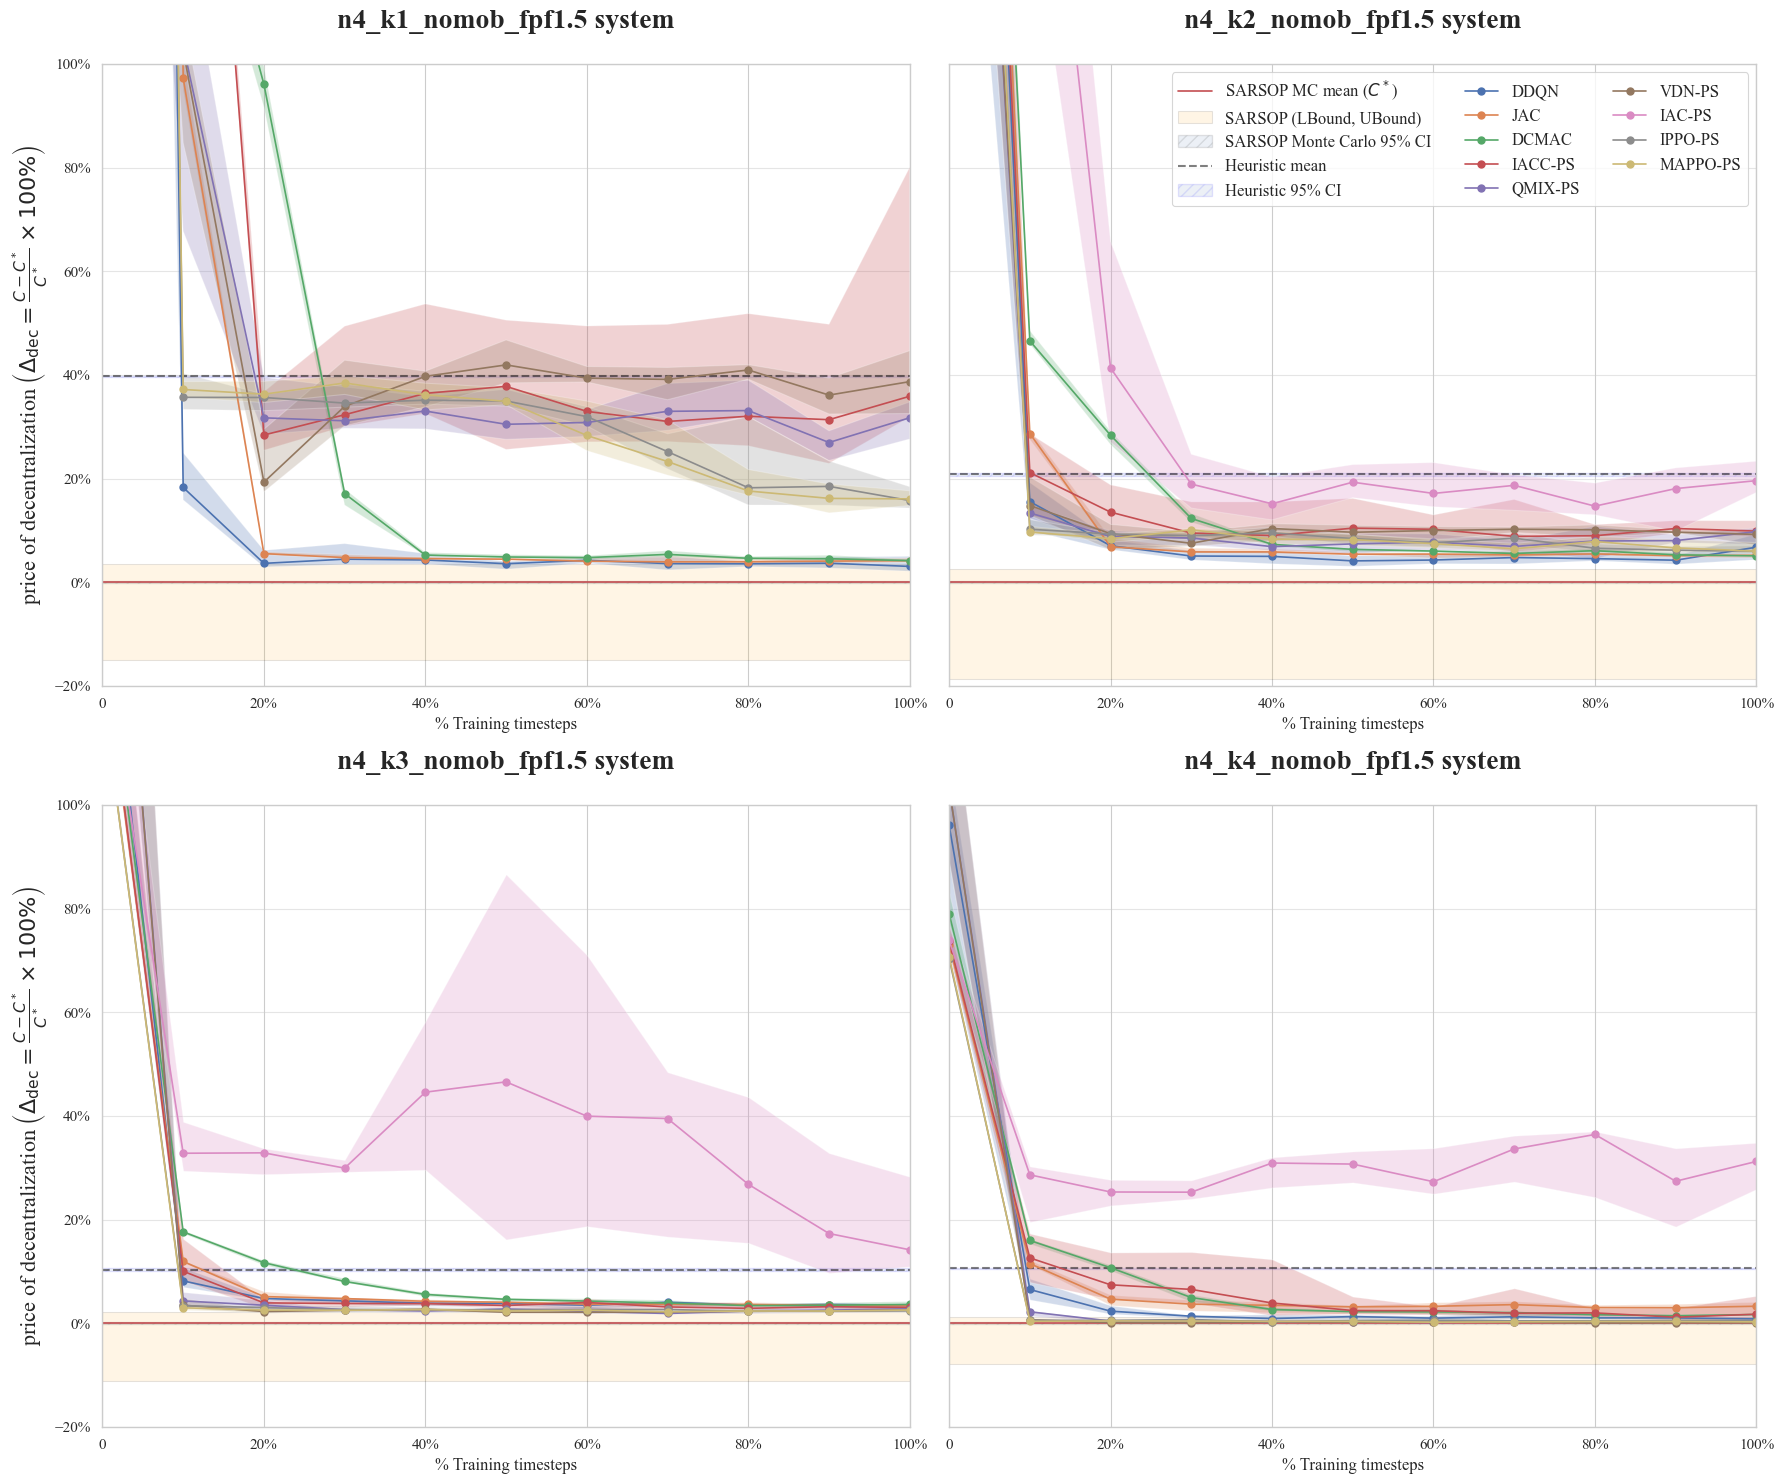

In [9]:
from matplotlib.ticker import PercentFormatter

ALG_LABEL_MAP = dict(zip(ALGORITHMS, ALGORITHM_NAMES))

fig, _ax = plt.subplots(2, 2, figsize=(18, 15), sharey=True)

for i, ax in enumerate(_ax.ravel()):
    setting_key = SETTINGS[i]  # "hard-k-of-4_infinite"
    setting_name = SETTING_NAMES[i]  # "k-out-of-4"

    # --- SARSOP baseline and bounds (normalized) ---
    sarsop = BASELINES[setting_key]["SARSOP"]
    sarsop_mean = sarsop["mean"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]

    rel_LBound = LBound / sarsop_mean - 1
    rel_UBound = UBound / sarsop_mean - 1

    ax.axhline(y=0.0, color="r", linestyle="-", label=r"SARSOP MC mean ($C^*$)")
    ax.fill_between(
        [0.0, 1.0],
        rel_LBound,
        rel_UBound,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)",
    )

    # SARSOP Monte Carlo 95% CI
    MC_95_ci = sarsop["95_ci"]
    MC_lower = MC_95_ci[0] / sarsop_mean - 1
    MC_upper = MC_95_ci[1] / sarsop_mean - 1
    ax.fill_between(
        [0.0, 1.0],
        MC_lower,
        MC_upper,
        color=None,
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        linewidth=1,
        label="SARSOP Monte Carlo 95% CI",
    )

    # --- Inspect–repair heuristic baseline (normalized) ---
    heur = BASELINES[setting_key]["InspectRepair"]
    H_mean, H_95_ci = heur["mean"], heur["95_ci"]
    H_lower = H_95_ci[0] / sarsop_mean - 1
    H_upper = H_95_ci[1] / sarsop_mean - 1

    ax.hlines(
        y=H_mean / sarsop_mean - 1,
        xmin=0.0,
        xmax=1.0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Heuristic mean",
    )
    ax.fill_between(
        [0.0, 1.0],
        H_lower,
        H_upper,
        color=None,
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        linewidth=1,
        label="Heuristic 95% CI",
    )

    # --- Learning curves: all checkpoints, per algorithm 0–100 percent ---
    data_setting = results_evals_df[results_evals_df["setting"] == setting_key]

    for alg in ALGORITHMS:
        sub = data_setting[data_setting["algorithm"] == alg]
        if sub.empty:
            continue

        # Aggregate across runs per checkpoint
        stats = (
            sub.groupby("checkpoint", observed=False)["mean"]
            .agg(
                median="median",
                q1=lambda x: x.quantile(0.25),
                q3=lambda x: x.quantile(0.75),
            )
            .sort_index()
        )

        # For this algorithm, map its own last checkpoint to 1.0
        chkpts = stats.index.to_numpy()
        max_chkpt_alg = chkpts.max()
        x_percent = chkpts / max_chkpt_alg

        y_median = stats["median"].to_numpy() / sarsop_mean - 1
        y_q1 = stats["q1"].to_numpy() / sarsop_mean - 1
        y_q3 = stats["q3"].to_numpy() / sarsop_mean - 1

        ax.plot(x_percent, y_median, "-o", label=ALG_LABEL_MAP[alg], markersize=5)
        ax.fill_between(x_percent, y_q1, y_q3, alpha=0.25)

    # --- Axes styling ---
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.2, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

    title = setting_name
    if setting_name == "1-out-of-4":
        title += " system\n (parallel configuration)"
    elif setting_name == "4-out-of-4":
        title += " system\n (series configuration)"
    else:
        title += " system\n"
    ax.set_title(title, fontdict={"weight": "bold"}, fontsize=20)

    ax.set_xlabel("% Training timesteps")
    ax.set_xticks(np.linspace(0.0, 1.0, 6))
    ax.set_xticklabels(["0", "20%", "40%", "60%", "80%", "100%"])

    if i % 2 == 0:
        ax.set_ylabel(r"price of decentralization $\left( \Delta_{\mathrm{dec}} = \frac{C - C^*}{C^*} \times 100\% \right)$", fontsize=16)

    ax.grid(axis="y", linestyle="-", alpha=0.5)

# --- Legend (deduplicate) ---
handles, labels = _ax[1, 1].get_legend_handles_labels()
unique = {}
for lbl, h in zip(labels, handles):
    if lbl and lbl not in unique:
        unique[lbl] = h

_ax[0, 1].legend(
    handles=list(unique.values()),
    labels=list(unique.keys()),
    loc="upper right",
    ncol=3,
    fontsize=12,
)

plt.tight_layout()
fig_name = "learning_curves_kn_infinite"
# plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)
plt.show()

### Tables

In [10]:
# --- Summary tables: best and median results per algorithm and setting ---
df_best = pd.DataFrame(columns=SETTING_NAMES)
df_median = pd.DataFrame(columns=SETTING_NAMES)

for s, (setting_key, setting_name) in enumerate(zip(SETTINGS, SETTING_NAMES)):
    # --- SARSOP baseline ---
    sarsop = BASELINES[setting_key]["SARSOP"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]
    MC_mean, MC_Lower, MC_Upper = sarsop["mean"], *sarsop["95_ci"]

    # Best
    df_best.loc["SARSOP (LBound, UBound)", setting_name] = (
        f"({LBound:.2f}, {UBound:.2f})"
    )
    df_best.loc["SARSOP MC", setting_name] = (
        f"{MC_mean:.2f} ({MC_Lower:.2f}, {MC_Upper:.2f})"
    )

    # Median (same entries for SARSOP)
    df_median.loc["SARSOP (LBound, UBound)", setting_name] = (
        f"({LBound:.2f}, {UBound:.2f})"
    )
    df_median.loc["SARSOP MC", setting_name] = (
        f"{MC_mean:.2f} ({MC_Lower:.2f}, {MC_Upper:.2f})"
    )

    # --- Inspect repair heuristic ---
    heur = BASELINES[setting_key]["InspectRepair"]
    H_mean, H_95_ci = heur["mean"], heur["95_ci"]

    df_best.loc["Heuristic", setting_name] = (
        f"{H_mean:.2f} ({H_95_ci[0]:.2f}, {H_95_ci[1]:.2f})"
    )
    df_median.loc["Heuristic", setting_name] = (
        f"{H_mean:.2f} ({H_95_ci[0]:.2f}, {H_95_ci[1]:.2f})"
    )

    # --- Learning algorithms ---
    for alg, alg_label in zip(ALGORITHMS, ALGORITHM_NAMES):
        data_sa = results_subset_df[
            (results_subset_df["setting"] == setting_key)
            & (results_subset_df["algorithm"] == alg)
        ]
        if data_sa.empty:
            continue

        y = data_sa["best_cost"].to_numpy()

        # Best: run with minimal best_cost and its CI
        idx_best = data_sa["best_cost"].idxmin()
        best_cost = data_sa.loc[idx_best, "best_cost"]
        ci_low = data_sa.loc[idx_best, "ci_low"]
        ci_high = data_sa.loc[idx_best, "ci_high"]

        df_best.loc[alg_label, setting_name] = (
            f"{best_cost:.2f} ({ci_low:.2f}, {ci_high:.2f})"
        )

        # Median: median across runs, with min max range
        median_cost = np.median(y)
        min_cost = np.min(y)
        max_cost = np.max(y)

        df_median.loc[alg_label, setting_name] = (
            f"{median_cost:.2f} ({min_cost:.2f}, {max_cost:.2f})"
        )

print("\nBest Results:")
display(df_best)

print("\nMedian Results:")
display(df_median)


Best Results:


,n4_k1_nomob_fpf1.5,n4_k2_nomob_fpf1.5,n4_k3_nomob_fpf1.5,n4_k4_nomob_fpf1.5
"SARSOP (LBound, UBound)","(28.52, 34.71)","(81.24, 102.43)","(203.12, 233.28)","(510.54, 561.00)"
SARSOP MC,"33.55 (33.47, 33.63)","99.86 (99.66, 100.07)","228.44 (227.98, 228.90)","554.07 (553.04, 555.10)"
Heuristic,"46.88 (46.84, 46.92)","120.68 (120.42, 120.93)","252.04 (251.46, 252.62)","612.73 (611.82, 613.64)"
DDQN,"33.95 (33.87, 34.03)","101.82 (101.65, 101.99)","232.79 (232.33, 233.26)","554.90 (553.87, 555.92)"
JAC,"34.51 (34.45, 34.58)","103.29 (103.08, 103.49)","233.59 (233.08, 234.09)","559.92 (558.88, 560.97)"
DCMAC,"34.65 (34.59, 34.72)","104.43 (104.23, 104.62)","234.47 (233.97, 234.97)","559.55 (558.51, 560.60)"
IACC-PS,"39.42 (39.42, 39.42)","102.88 (102.68, 103.08)","231.98 (231.50, 232.46)","554.68 (553.65, 555.72)"
QMIX-PS,"39.01 (38.94, 39.08)","103.89 (103.70, 104.08)","231.87 (231.35, 232.40)","553.18 (552.16, 554.20)"
VDN-PS,"39.34 (39.25, 39.42)","103.99 (103.79, 104.18)","232.04 (231.51, 232.56)","553.22 (552.19, 554.24)"
IAC-PS,"49.76 (49.67, 49.85)","106.37 (106.14, 106.59)","237.71 (237.21, 238.22)","620.95 (619.93, 621.96)"



Median Results:


,n4_k1_nomob_fpf1.5,n4_k2_nomob_fpf1.5,n4_k3_nomob_fpf1.5,n4_k4_nomob_fpf1.5
"SARSOP (LBound, UBound)","(28.52, 34.71)","(81.24, 102.43)","(203.12, 233.28)","(510.54, 561.00)"
SARSOP MC,"33.55 (33.47, 33.63)","99.86 (99.66, 100.07)","228.44 (227.98, 228.90)","554.07 (553.04, 555.10)"
Heuristic,"46.88 (46.84, 46.92)","120.68 (120.42, 120.93)","252.04 (251.46, 252.62)","612.73 (611.82, 613.64)"
DDQN,"34.25 (33.95, 34.67)","102.74 (101.82, 104.95)","235.06 (232.79, 236.56)","556.31 (554.90, 559.52)"
JAC,"34.80 (34.51, 35.03)","104.85 (103.29, 105.50)","235.32 (233.59, 237.58)","569.78 (559.92, 579.11)"
DCMAC,"34.93 (34.65, 35.17)","104.95 (104.43, 105.34)","235.89 (234.47, 236.51)","561.15 (559.55, 563.33)"
IACC-PS,"41.49 (39.42, 111.12)","106.61 (102.88, 116.92)","234.13 (231.98, 236.46)","560.53 (554.68, 682.37)"
QMIX-PS,"41.37 (39.01, 42.69)","104.62 (103.89, 106.64)","232.47 (231.87, 233.39)","553.98 (553.18, 554.21)"
VDN-PS,"40.03 (39.34, 44.06)","106.21 (103.99, 107.37)","232.90 (232.04, 233.36)","553.80 (553.22, 554.34)"
IAC-PS,"111.12 (49.76, 111.12)","111.45 (106.37, 121.49)","258.55 (237.71, 305.88)","653.22 (620.95, 707.52)"


# n3_nomob

In [11]:
# Load data
results_summary_df = pd.read_csv("./data/results_summary.csv")
results_evals_df = pd.read_csv("./data/results_evals.csv")

ENV_NAME = "k_out_of_n_infinite"
SETTINGS = [f"n3_k{k}_nomob" for k in range(1, 4)]
SETTING_NAMES = [f"n3_k{k}_nomob" for k in range(1, 4)]

ALGORITHMS = results_summary_df["algorithm"].unique().tolist()
ALGORITHM_NAMES = [alg.replace("_", "-").upper() for alg in ALGORITHMS]
RANDOM_SEEDS = 10

BASELINES = {}
for setting in SETTINGS:
    env = imprl.envs.make(ENV_NAME, setting)
    BASELINES[setting] = env.core.baselines

### Box Plots

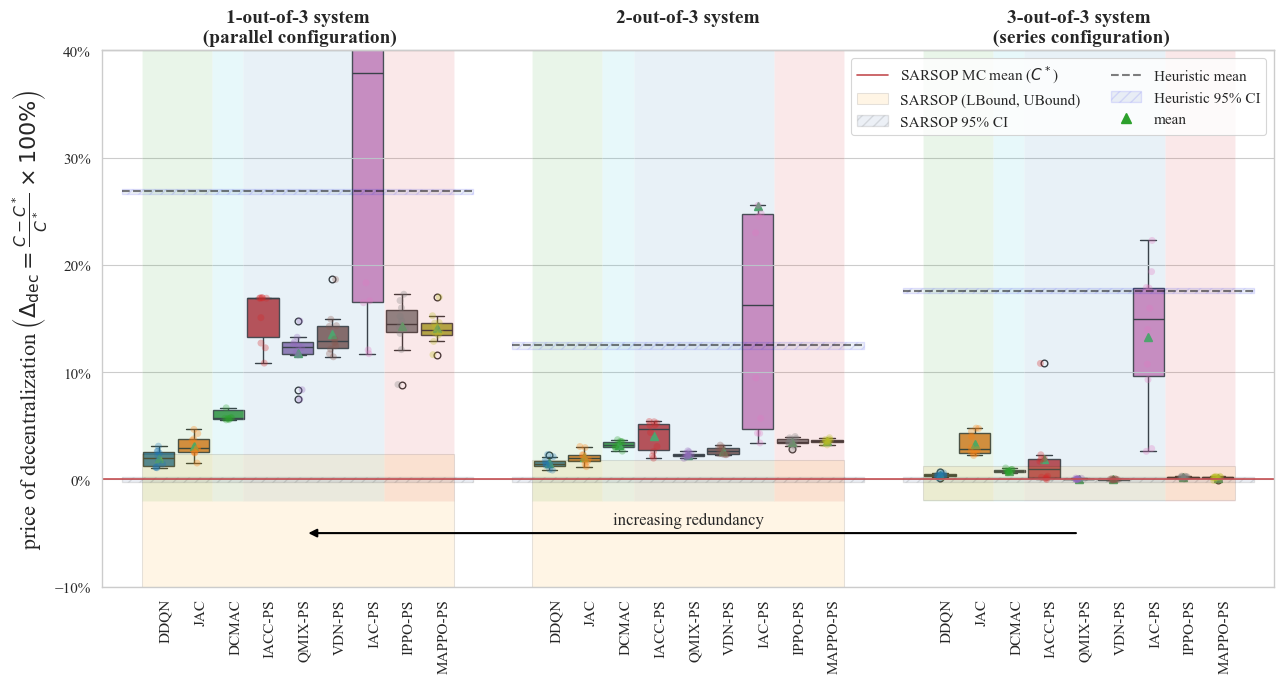

In [12]:
from matplotlib.ticker import PercentFormatter

results_subset_df = results_summary_df[
    results_summary_df["algorithm"].isin(ALGORITHMS)
    & results_summary_df["setting"].isin(SETTINGS)
].copy()


# Enforce plotting order
results_subset_df["setting"] = pd.Categorical(
    results_subset_df["setting"], categories=SETTINGS, ordered=False
)
results_subset_df["algorithm"] = pd.Categorical(
    results_subset_df["algorithm"], categories=ALGORITHMS, ordered=False
)
results_subset_df = results_subset_df.sort_values(["algorithm", "setting"])

# --- Figure + axis ---
fig, ax = plt.subplots(figsize=(13, 7))
ax.grid(axis="x", linestyle="-", alpha=0.01)

# --- Shaded bands for MADRL paradigms along x ---
_patch_alpha, ymin, ymax = 0.1, 0.16, 1.0
for c in range(len(SETTINGS)):
    ax.axvspan(
        -0.4 + c, -0.22 + c, ymin, ymax, facecolor="tab:green", alpha=_patch_alpha
    )  # CTCE (POMDP)
    ax.axvspan(
        -0.22 + c, -0.14 + c, ymin, ymax, facecolor="tab:cyan", alpha=_patch_alpha
    )  # CTCE (MPOMDP)
    ax.axvspan(
        -0.14 + c, 0.22 + c, ymin, ymax, facecolor="tab:blue", alpha=_patch_alpha
    )  # CTDE (Dec-POMDP)
    ax.axvspan(
        0.22 + c, 0.40 + c, ymin, ymax, facecolor="tab:red", alpha=_patch_alpha
    )  # DTDE (Dec-POMDP)

# --- Box + strip over normalized_best_cost ---
sns.boxplot(
    data=results_subset_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    palette="tab10",
    showmeans=True,
    linewidth=1,
    gap=0.1,
    zorder=0,
    legend=False,
    boxprops=dict(alpha=0.9),
)
sns.stripplot(
    data=results_subset_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    palette="tab10",
    dodge=True,
    alpha=0.3,
    jitter=0.1,
    zorder=2,
    legend=False,
)

# --- Replace x-ticks by algorithm names (grouped by setting) ---
all_patches = [p for p in ax.patches if isinstance(p, matplotlib.patches.PathPatch)]

positions = []
for patch in all_patches:
    verts = patch.get_path().vertices
    box_x = verts[0:2, 0].mean()
    positions.append(box_x)
positions = sorted(positions)

labels = ALGORITHM_NAMES * len(SETTINGS)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, ha="left")
ax.set_xlabel(None)

# --- SARSOP baseline at zero (normalized) ---
ax.axhline(y=0.0, color="r", linestyle="-", label=r"SARSOP MC mean ($C^*$)")

ax.set_xlim(-0.5, len(SETTINGS) - 0.5)
ax.set_ylim(-0.1, 0.4)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel(r"price of decentralization $\left( \Delta_{\mathrm{dec}} = \frac{C - C^*}{C^*} \times 100\% \right)$", fontsize=16)

# --- Redundancay arrow below ---
_top_arrow_y = -0.05
ax.text(
    len(SETTINGS) / 2 - 0.5,
    _top_arrow_y + 0.005,
    "increasing redundancy",
    fontsize=12,
    ha="center",
    va="bottom",
)
ax.annotate(
    "",
    xy=(0.02, _top_arrow_y),
    xytext=(len(SETTINGS) - 1, _top_arrow_y),
    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5),
)

# -------------------- Heuristics and baselines --------------------
for s, setting in enumerate(SETTINGS):
    sarsop = BASELINES[setting]["SARSOP"]
    mean_sarsop = sarsop["mean"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]

    # SARSOP LBound–UBound band (normalized)
    rel_LBound = LBound / mean_sarsop - 1
    rel_UBound = UBound / mean_sarsop - 1
    ax.fill_between(
        [s - 0.4, s + 0.4],
        rel_LBound,
        rel_UBound,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)",
    )

    # SARSOP Monte Carlo 95% CI (normalized)
    MC_mean, MC_95_ci = sarsop["mean"], sarsop["95_ci"]
    MC_lower = MC_95_ci[0] / MC_mean - 1
    MC_upper = MC_95_ci[1] / MC_mean - 1
    ax.fill_between(
        [s - 0.45, s + 0.45],
        MC_lower,
        MC_upper,
        color=None,
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        linewidth=1,
        label="SARSOP 95% CI",
    )

    # Heuristic: Inspect–repair (normalized)
    heur = BASELINES[setting]["InspectRepair"]
    H_mean, H_95_ci = heur["mean"], heur["95_ci"]
    H_lower = H_95_ci[0] / MC_mean - 1
    H_upper = H_95_ci[1] / MC_mean - 1

    ax.hlines(
        y=H_mean / MC_mean - 1,
        xmin=s - 0.45,
        xmax=s + 0.45,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Heuristic mean",
    )
    ax.fill_between(
        [s - 0.45, s + 0.45],
        H_lower,
        H_upper,
        color=None,
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        linewidth=1,
        label="Heuristic 95% CI",
    )

# --- Secondary x-axis with k-out-of-3 labels (auto from len(SETTINGS)) ---
n = len(SETTINGS)
titles = []
for i in range(n):
    if i == 0:
        titles.append(f"1-out-of-{n} system\n (parallel configuration)")
    elif i == n - 1:
        titles.append(f"{n}-out-of-{n} system\n (series configuration)")
    else:
        titles.append(f"{i+1}-out-of-{n} system\n ")
secax = ax.secondary_xaxis("top")
ticks = np.arange(n)
secax.set_xticks(ticks)
secax.set_xticklabels(titles, fontsize=14, fontdict={"weight": "bold"})
secax.tick_params(axis="x", which="both", length=0)

# --- Legend: algorithms + baselines + mean marker, de-duplicated ---
auto_handles, auto_labels = ax.get_legend_handles_labels()

mean_marker = Line2D(
    [0],
    [0],
    color="tab:green",
    marker="^",
    linestyle="None",
    markersize=5,
    label="mean",
)

all_handles = list(auto_handles) + [mean_marker]
all_labels = [h.get_label() for h in all_handles]

unique = {}
for lbl, h in zip(all_labels, all_handles):
    if lbl and lbl not in unique:
        unique[lbl] = h

ax.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    ncol=2,
    markerscale=1.5,
)

plt.tight_layout()

fig_name = "boxplot_n3_nomob"
# plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)

plt.show()

### Learning Curves

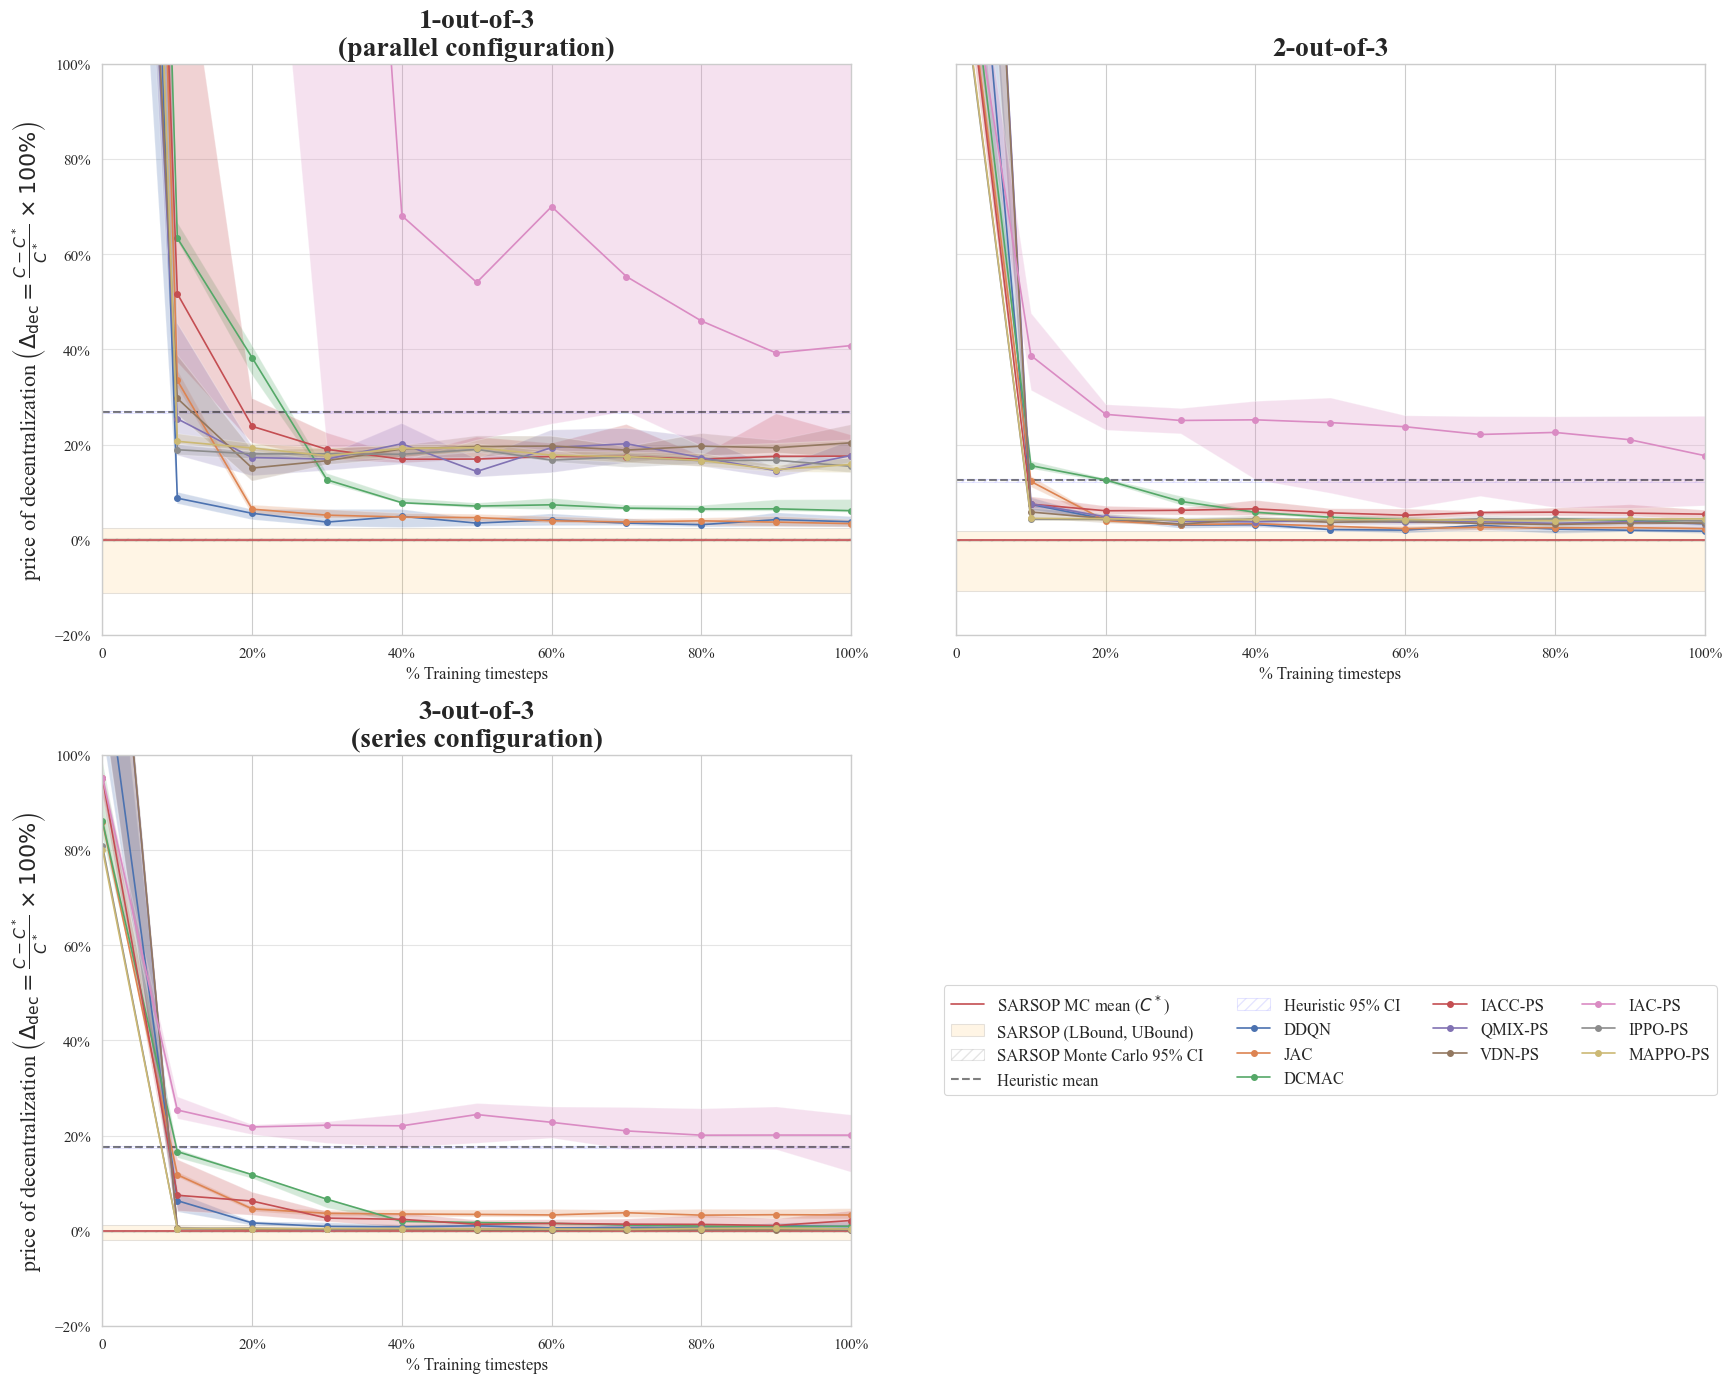

In [13]:
from matplotlib.ticker import PercentFormatter

ALG_LABEL_MAP = dict(zip(ALGORITHMS, ALGORITHM_NAMES))

# --- 2×2 mosaic: A B / C D (D = legend panel) ---
mosaic = """
AB
CD
"""
fig = plt.figure(figsize=(18, 14))
axes = fig.subplot_mosaic(mosaic, sharey=True)

axA = axes["A"]
axB = axes["B"]
axC = axes["C"]
axD = axes["D"]  # legend panel

axis_order = [axA, axB, axC]

# ---------------------- Populate A, B, C ----------------------
for i, ax in enumerate(axis_order):
    setting_key = SETTINGS[i]
    n = len(SETTINGS)
    k = i + 1

    # Titles
    if k == 1:
        setting_name = f"{k}-out-of-{n}\n(parallel configuration)"
    elif k == n:
        setting_name = f"{k}-out-of-{n}\n(series configuration)"
    else:
        setting_name = f"{k}-out-of-{n}"

    # --- SARSOP baseline (normalized) ---
    sarsop = BASELINES[setting_key]["SARSOP"]
    sarsop_mean = sarsop["mean"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]

    ax.axhline(0, color="r", lw=1.2, label=r"SARSOP MC mean ($C^*$)")
    ax.fill_between(
        [0, 1],
        LBound / sarsop_mean - 1,
        UBound / sarsop_mean - 1,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)",
    )

    # SARSOP MC CI
    lo, hi = sarsop["95_ci"]
    ax.fill_between(
        [0, 1],
        lo / sarsop_mean - 1,
        hi / sarsop_mean - 1,
        color="none",
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        label="SARSOP Monte Carlo 95% CI",
    )

    # --- Heuristic baseline ---
    heur = BASELINES[setting_key]["InspectRepair"]
    Hm, (Hl, Hu) = heur["mean"], heur["95_ci"]

    ax.hlines(
        Hm / sarsop_mean - 1,
        xmin=0,
        xmax=1,
        color="black",
        ls="--",
        lw=1.5,
        alpha=0.5,
        label="Heuristic mean",
    )
    ax.fill_between(
        [0, 1],
        Hl / sarsop_mean - 1,
        Hu / sarsop_mean - 1,
        color="none",
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        label="Heuristic 95% CI",
    )

    # --- Learning curves (0–1 normalized per algorithm) ---
    data_setting = results_evals_df[results_evals_df["setting"] == setting_key]

    for alg in ALGORITHMS:
        sub = data_setting[data_setting["algorithm"] == alg]
        if sub.empty:
            continue

        stats = (
            sub.groupby("checkpoint", observed=False)["mean"]
            .agg(
                median="median",
                q1=lambda x: x.quantile(0.25),
                q3=lambda x: x.quantile(0.75),
            )
            .sort_index()
        )

        chkpts = stats.index.to_numpy()
        x = chkpts / chkpts.max()  # scale individually
        y_med = stats["median"].to_numpy() / sarsop_mean - 1
        y_q1 = stats["q1"].to_numpy() / sarsop_mean - 1
        y_q3 = stats["q3"].to_numpy() / sarsop_mean - 1

        ax.plot(x, y_med, "-o", ms=4, label=ALG_LABEL_MAP[alg])
        ax.fill_between(x, y_q1, y_q3, alpha=0.25)

    # Styling
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.2, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_title(setting_name, fontsize=20, fontweight="bold")
    ax.set_xlabel("% Training timesteps")
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xticklabels(["0", "20%", "40%", "60%", "80%", "100%"])

    if ax in (axA, axC):  # left column only
        ax.set_ylabel(r"price of decentralization $\left( \Delta_{\mathrm{dec}} = \frac{C - C^*}{C^*} \times 100\% \right)$", fontsize=16)

    ax.grid(axis="y", alpha=0.5)

# ------------------ Legend panel (D) ------------------
# Hide axes frame and ticks
axD.set_axis_off()

# Collect legend entries from one actual panel
h, l = axC.get_legend_handles_labels()
unique = {}
for label, handle in zip(l, h):
    if label not in unique:
        unique[label] = handle

axD.legend(
    unique.values(), unique.keys(), loc="center", ncol=4, fontsize=12, frameon=True
)

plt.tight_layout()

fig_name = "learning_curves_n3_nomob"
# plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches='tight', transparent=True)
plt.show()

### Tables

In [11]:
# --- Summary tables: best and median results per algorithm and setting ---
df_best = pd.DataFrame(columns=SETTING_NAMES)
df_median = pd.DataFrame(columns=SETTING_NAMES)

for s, (setting_key, setting_name) in enumerate(zip(SETTINGS, SETTING_NAMES)):
    # --- SARSOP baseline ---
    sarsop = BASELINES[setting_key]["SARSOP"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]
    MC_mean, MC_Lower, MC_Upper = sarsop["mean"], *sarsop["95_ci"]

    # Best
    df_best.loc["SARSOP (LBound, UBound)", setting_name] = (
        f"({LBound:.2f}, {UBound:.2f})"
    )
    df_best.loc["SARSOP MC", setting_name] = (
        f"{MC_mean:.2f} ({MC_Lower:.2f}, {MC_Upper:.2f})"
    )

    # Median (same entries for SARSOP)
    df_median.loc["SARSOP (LBound, UBound)", setting_name] = (
        f"({LBound:.2f}, {UBound:.2f})"
    )
    df_median.loc["SARSOP MC", setting_name] = (
        f"{MC_mean:.2f} ({MC_Lower:.2f}, {MC_Upper:.2f})"
    )

    # --- Inspect repair heuristic ---
    heur = BASELINES[setting_key]["InspectRepair"]
    H_mean, H_95_ci = heur["mean"], heur["95_ci"]

    df_best.loc["Heuristic", setting_name] = (
        f"{H_mean:.2f} ({H_95_ci[0]:.2f}, {H_95_ci[1]:.2f})"
    )
    df_median.loc["Heuristic", setting_name] = (
        f"{H_mean:.2f} ({H_95_ci[0]:.2f}, {H_95_ci[1]:.2f})"
    )

    # --- Learning algorithms ---
    for alg, alg_label in zip(ALGORITHMS, ALGORITHM_NAMES):
        data_sa = results_subset_df[
            (results_subset_df["setting"] == setting_key)
            & (results_subset_df["algorithm"] == alg)
        ]
        if data_sa.empty:
            continue

        y = data_sa["best_cost"].to_numpy()

        # Best: run with minimal best_cost and its CI
        idx_best = data_sa["best_cost"].idxmin()
        best_cost = data_sa.loc[idx_best, "best_cost"]
        ci_low = data_sa.loc[idx_best, "ci_low"]
        ci_high = data_sa.loc[idx_best, "ci_high"]

        df_best.loc[alg_label, setting_name] = (
            f"{best_cost:.2f} ({ci_low:.2f}, {ci_high:.2f})"
        )

        # Median: median across runs, with min max range
        median_cost = np.median(y)
        min_cost = np.min(y)
        max_cost = np.max(y)

        df_median.loc[alg_label, setting_name] = (
            f"{median_cost:.2f} ({min_cost:.2f}, {max_cost:.2f})"
        )

print("\nBest Results:")
display(df_best)

print("\nMedian Results:")
display(df_median)


Best Results:


,n3_k1_nomob,n3_k2_nomob,n3_k3_nomob
"SARSOP (LBound, UBound)","(40.47, 46.70)","(127.23, 145.06)","(410.91, 424.17)"
SARSOP MC,"45.62 (45.51, 45.74)","142.46 (142.16, 142.76)","419.04 (418.01, 420.06)"
Heuristic,"57.88 (57.77, 57.99)","160.31 (159.85, 160.78)","492.84 (491.81, 493.87)"
DDQN,"46.12 (46.01, 46.23)","143.71 (143.42, 144.00)","419.47 (418.43, 420.52)"
JAC,"46.32 (46.20, 46.43)","144.16 (143.86, 144.46)","428.41 (427.44, 429.38)"
DCMAC,"48.16 (48.04, 48.27)","146.22 (145.88, 146.57)","421.67 (420.68, 422.66)"
IACC-PS,"50.57 (50.45, 50.69)","145.29 (144.98, 145.60)","419.03 (418.06, 420.01)"
QMIX-PS,"49.02 (48.92, 49.12)","145.26 (144.95, 145.58)","419.03 (418.01, 420.05)"
VDN-PS,"50.84 (50.73, 50.94)","145.75 (145.43, 146.06)","418.73 (417.76, 419.70)"
IAC-PS,"50.97 (50.83, 51.11)","147.31 (147.03, 147.59)","430.02 (429.15, 430.90)"



Median Results:


,n3_k1_nomob,n3_k2_nomob,n3_k3_nomob
"SARSOP (LBound, UBound)","(40.47, 46.70)","(127.23, 145.06)","(410.91, 424.17)"
SARSOP MC,"45.62 (45.51, 45.74)","142.46 (142.16, 142.76)","419.04 (418.01, 420.06)"
Heuristic,"57.88 (57.77, 57.99)","160.31 (159.85, 160.78)","492.84 (491.81, 493.87)"
DDQN,"46.52 (46.12, 47.04)","144.55 (143.71, 145.77)","420.68 (419.47, 422.06)"
JAC,"46.94 (46.32, 47.75)","145.27 (144.16, 146.84)","431.11 (428.41, 439.09)"
DCMAC,"48.23 (48.16, 180.25)","146.97 (146.22, 147.75)","422.21 (421.67, 423.53)"
IACC-PS,"53.33 (50.57, 180.00)","149.20 (145.29, 150.17)","423.25 (419.03, 464.38)"
QMIX-PS,"51.27 (49.02, 52.36)","145.71 (145.26, 146.26)","419.13 (419.03, 419.58)"
VDN-PS,"51.52 (50.84, 54.13)","146.21 (145.75, 147.02)","419.12 (418.73, 419.35)"
IAC-PS,"62.90 (50.97, 180.00)","165.58 (147.31, 327.67)","481.79 (430.02, 512.43)"


## n2_nomob

In [12]:
# Load data
results_summary_df = pd.read_csv("./data/results_summary.csv")
results_evals_df = pd.read_csv("./data/results_evals.csv")

ENV_NAME = "k_out_of_n_infinite"
SETTINGS = [f"n2_k{k}_nomob" for k in range(1, 3)]
SETTING_NAMES = [f"n2_k{k}_nomob" for k in range(1, 3)]

ALGORITHMS = results_summary_df["algorithm"].unique().tolist()
ALGORITHM_NAMES = [alg.replace("_", "-").upper() for alg in ALGORITHMS]
RANDOM_SEEDS = 10

BASELINES = {}
for setting in SETTINGS:
    env = imprl.envs.make(ENV_NAME, setting)
    BASELINES[setting] = env.core.baselines

### Box Plots

In [ ]:
from matplotlib.ticker import PercentFormatter

# --- Settings and baselines for n2_nomob ---
SETTINGS = [f"n2_k{k}_nomob" for k in range(1, 3)]

results_subset_df = results_summary_df[
    results_summary_df["algorithm"].isin(ALGORITHMS)
    & results_summary_df["setting"].isin(SETTINGS)
].copy()

# enforce plotting order
results_subset_df["setting"] = pd.Categorical(
    results_subset_df["setting"], categories=SETTINGS, ordered=False
)
results_subset_df["algorithm"] = pd.Categorical(
    results_subset_df["algorithm"], categories=ALGORITHMS, ordered=False
)
results_subset_df = results_subset_df.sort_values(["algorithm", "setting"])

# baselines
ENV_NAME = "k_out_of_n_infinite"
BASELINES = {}
for setting in SETTINGS:
    env = imprl.envs.make(ENV_NAME, setting)
    BASELINES[setting] = env.core.baselines

# --- figure ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(axis="x", linestyle="-", alpha=0.01)

# shaded MADRL bands
_patch_alpha, ymin, ymax = 0.1, 0.16, 1.0
for c in range(len(SETTINGS)):
    ax.axvspan(
        -0.4 + c, -0.22 + c, ymin, ymax, facecolor="tab:green", alpha=_patch_alpha
    )  # CTCE (POMDP)
    ax.axvspan(
        -0.22 + c, -0.14 + c, ymin, ymax, facecolor="tab:cyan", alpha=_patch_alpha
    )  # CTCE (MPOMDP)
    ax.axvspan(
        -0.14 + c, 0.22 + c, ymin, ymax, facecolor="tab:blue", alpha=_patch_alpha
    )  # CTDE (Dec-POMDP)
    ax.axvspan(
        0.22 + c, 0.40 + c, ymin, ymax, facecolor="tab:red", alpha=_patch_alpha
    )  # DTDE (Dec-POMDP)

# box + strip over normalized_best_cost
sns.boxplot(
    data=results_subset_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    palette="tab10",
    showmeans=True,
    linewidth=1,
    gap=0.1,
    zorder=0,
    legend=False,
    boxprops=dict(alpha=0.9),
)
sns.stripplot(
    data=results_subset_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    palette="tab10",
    dodge=True,
    alpha=0.3,
    jitter=0.1,
    zorder=2,
    legend=False,
)

# replace x-ticks by algorithm names
all_patches = [p for p in ax.patches if isinstance(p, matplotlib.patches.PathPatch)]
positions = []
for patch in all_patches:
    verts = patch.get_path().vertices
    positions.append(verts[0:2, 0].mean())
positions = sorted(positions)

labels = ALGORITHM_NAMES * len(SETTINGS)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, ha="left")
ax.set_xlabel(None)

# SARSOP baseline at zero
ax.axhline(0.0, color="r", linestyle="-", label=r"SARSOP MC mean ($C^*$)")
ax.set_xlim(-0.5, len(SETTINGS) - 0.5)
ax.set_ylim(-0.1, 0.4)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel(r"price of decentralization $\left( \Delta_{\mathrm{dec}} = \frac{C - C^*}{C^*} \times 100\% \right)$", fontsize=14)

# --- Redundancay arrow below ---
_top_arrow_y = -0.05
ax.text(
    len(SETTINGS) / 2 - 0.5,
    _top_arrow_y + 0.005,
    "increasing redundancy",
    fontsize=12,
    ha="center",
    va="bottom",
)
ax.annotate(
    "",
    xy=(0.02, _top_arrow_y),
    xytext=(len(SETTINGS) - 1, _top_arrow_y),
    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5),
)

# baselines + heuristic bands
for s, setting in enumerate(SETTINGS):
    sarsop = BASELINES[setting]["SARSOP"]
    mean_sarsop = sarsop["mean"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]

    # SARSOP LBound–UBound
    ax.fill_between(
        [s - 0.4, s + 0.4],
        LBound / mean_sarsop - 1,
        UBound / mean_sarsop - 1,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)",
    )

    # SARSOP MC 95% CI
    lo, hi = sarsop["95_ci"]
    ax.fill_between(
        [s - 0.45, s + 0.45],
        lo / mean_sarsop - 1,
        hi / mean_sarsop - 1,
        color="none",
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        linewidth=1,
        label="SARSOP 95% CI",
    )

    # heuristic
    heur = BASELINES[setting]["InspectRepair"]
    Hm, (Hl, Hu) = heur["mean"], heur["95_ci"]
    ax.hlines(
        Hm / mean_sarsop - 1,
        s - 0.45,
        s + 0.45,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Heuristic mean",
    )
    ax.fill_between(
        [s - 0.45, s + 0.45],
        Hl / mean_sarsop - 1,
        Hu / mean_sarsop - 1,
        color="none",
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        linewidth=1,
        label="Heuristic 95% CI",
    )

# top axis labels 1-out-of-2 / 2-out-of-2
n = len(SETTINGS)
titles = []
for i in range(n):
    k = i + 1
    if k == 1:
        titles.append(f"{k}-out-of-{n} system\n (parallel configuration)")
    else:
        titles.append(f"{k}-out-of-{n} system\n (series configuration)")

secax = ax.secondary_xaxis("top")
secax.set_xticks(np.arange(n))
secax.set_xticklabels(titles, fontsize=12, fontdict={"weight": "bold"})
secax.tick_params(axis="x", which="both", length=0)

# legend
auto_handles, auto_labels = ax.get_legend_handles_labels()
mean_marker = Line2D(
    [0],
    [0],
    color="tab:green",
    marker="^",
    linestyle="None",
    markersize=5,
    label="mean",
)

all_handles = list(auto_handles) + [mean_marker]
all_labels = [h.get_label() for h in all_handles]
unique = {}
for lbl, h in zip(all_labels, all_handles):
    if lbl and lbl not in unique:
        unique[lbl] = h

ax.legend(unique.values(), unique.keys(), loc="upper right", ncol=2, markerscale=1.5)

plt.tight_layout()
fig_name = "boxplot_n2_nomob"
# plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)
plt.show()

### Learning Curves

In [ ]:
from matplotlib.ticker import PercentFormatter

ALG_LABEL_MAP = dict(zip(ALGORITHMS, ALGORITHM_NAMES))

# Subset evals for n2_nomob
evals_n2 = results_evals_df[
    results_evals_df["setting"].isin(SETTINGS)
    & results_evals_df["algorithm"].isin(ALGORITHMS)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, ax in enumerate(axes):
    setting_key = SETTINGS[i]
    n = len(SETTINGS)
    k = i + 1

    # Titles: 1-out-of-2 (parallel) / 2-out-of-2 (series)
    if k == 1:
        title = f"{k}-out-of-{n} system\n(parallel configuration)"
    else:
        title = f"{k}-out-of-{n} system\n(series configuration)"

    # --- SARSOP baseline and bounds (normalized) ---
    sarsop = BASELINES[setting_key]["SARSOP"]
    sarsop_mean = sarsop["mean"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]

    ax.axhline(0, color="r", lw=1.2, label=r"SARSOP MC mean ($C^*$)")
    ax.fill_between(
        [0, 1],
        LBound / sarsop_mean - 1,
        UBound / sarsop_mean - 1,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)",
    )

    # SARSOP MC 95% CI
    lo, hi = sarsop["95_ci"]
    ax.fill_between(
        [0, 1],
        lo / sarsop_mean - 1,
        hi / sarsop_mean - 1,
        color="none",
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        linewidth=1,
        label="SARSOP Monte Carlo 95% CI",
    )

    # --- Heuristic: Inspect–repair baseline (normalized) ---
    heur = BASELINES[setting_key]["InspectRepair"]
    Hm, (Hl, Hu) = heur["mean"], heur["95_ci"]

    ax.hlines(
        Hm / sarsop_mean - 1,
        xmin=0,
        xmax=1,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Heuristic mean",
    )
    ax.fill_between(
        [0, 1],
        Hl / sarsop_mean - 1,
        Hu / sarsop_mean - 1,
        color="none",
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        linewidth=1,
        label="Heuristic 95% CI",
    )

    # --- Learning curves: per algorithm, scaled 0–1 on x ---
    data_setting = evals_n2[evals_n2["setting"] == setting_key]

    for alg in ALGORITHMS:
        sub = data_setting[data_setting["algorithm"] == alg]
        if sub.empty:
            continue

        stats = (
            sub.groupby("checkpoint", observed=False)["mean"]
            .agg(
                median="median",
                q1=lambda x: x.quantile(0.25),
                q3=lambda x: x.quantile(0.75),
            )
            .sort_index()
        )

        chkpts = stats.index.to_numpy()
        x = chkpts / chkpts.max()  # per-algorithm 0–1 scaling

        y_med = stats["median"].to_numpy() / sarsop_mean - 1
        y_q1 = stats["q1"].to_numpy() / sarsop_mean - 1
        y_q3 = stats["q3"].to_numpy() / sarsop_mean - 1

        ax.plot(x, y_med, "-o", ms=4, label=ALG_LABEL_MAP[alg])
        ax.fill_between(x, y_q1, y_q3, alpha=0.25)

    # Styling
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.2, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("% Training timesteps")
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xticklabels(["0", "20%", "40%", "60%", "80%", "100%"])
    ax.grid(axis="y", alpha=0.5)

    if i == 0:
        ax.set_ylabel(r"price of decentralization $\left( \Delta_{\mathrm{dec}} = \frac{C - C^*}{C^*} \times 100\% \right)$", fontsize=14)

# --- Legend at the bottom (deduplicated) ---
handles, labels = axes[1].get_legend_handles_labels()
unique = {}
for lbl, h in zip(labels, handles):
    if lbl and lbl not in unique:
        unique[lbl] = h

fig.legend(
    handles=list(unique.values()),
    labels=list(unique.keys()),
    loc="lower center",
    ncol=4,
    fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
fig_name = "learning_curves_n2_nomob"
# plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)
plt.show()

### Tables

In [15]:
# --- Summary tables: best and median results per algorithm and setting ---
df_best = pd.DataFrame(columns=SETTING_NAMES)
df_median = pd.DataFrame(columns=SETTING_NAMES)

for s, (setting_key, setting_name) in enumerate(zip(SETTINGS, SETTING_NAMES)):
    # --- SARSOP baseline ---
    sarsop = BASELINES[setting_key]["SARSOP"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]
    MC_mean, MC_Lower, MC_Upper = sarsop["mean"], *sarsop["95_ci"]

    # Best
    df_best.loc["SARSOP (LBound, UBound)", setting_name] = (
        f"({LBound:.2f}, {UBound:.2f})"
    )
    df_best.loc["SARSOP MC", setting_name] = (
        f"{MC_mean:.2f} ({MC_Lower:.2f}, {MC_Upper:.2f})"
    )

    # Median (same entries for SARSOP)
    df_median.loc["SARSOP (LBound, UBound)", setting_name] = (
        f"({LBound:.2f}, {UBound:.2f})"
    )
    df_median.loc["SARSOP MC", setting_name] = (
        f"{MC_mean:.2f} ({MC_Lower:.2f}, {MC_Upper:.2f})"
    )

    # --- Inspect repair heuristic ---
    heur = BASELINES[setting_key]["InspectRepair"]
    H_mean, H_95_ci = heur["mean"], heur["95_ci"]

    df_best.loc["Heuristic", setting_name] = (
        f"{H_mean:.2f} ({H_95_ci[0]:.2f}, {H_95_ci[1]:.2f})"
    )
    df_median.loc["Heuristic", setting_name] = (
        f"{H_mean:.2f} ({H_95_ci[0]:.2f}, {H_95_ci[1]:.2f})"
    )

    # --- Learning algorithms ---
    for alg, alg_label in zip(ALGORITHMS, ALGORITHM_NAMES):
        data_sa = results_subset_df[
            (results_subset_df["setting"] == setting_key)
            & (results_subset_df["algorithm"] == alg)
        ]
        if data_sa.empty:
            continue

        y = data_sa["best_cost"].to_numpy()

        # Best: run with minimal best_cost and its CI
        idx_best = data_sa["best_cost"].idxmin()
        best_cost = data_sa.loc[idx_best, "best_cost"]
        ci_low = data_sa.loc[idx_best, "ci_low"]
        ci_high = data_sa.loc[idx_best, "ci_high"]

        df_best.loc[alg_label, setting_name] = (
            f"{best_cost:.2f} ({ci_low:.2f}, {ci_high:.2f})"
        )

        # Median: median across runs, with min max range
        median_cost = np.median(y)
        min_cost = np.min(y)
        max_cost = np.max(y)

        df_median.loc[alg_label, setting_name] = (
            f"{median_cost:.2f} ({min_cost:.2f}, {max_cost:.2f})"
        )

print("\nBest Results:")
display(df_best)

print("\nMedian Results:")
display(df_median)


Best Results:


,n2_k1_nomob,n2_k2_nomob
"SARSOP (LBound, UBound)","(53.40, 53.72)","(193.40, 193.47)"
SARSOP MC,"52.71 (52.56, 52.85)","191.19 (190.69, 191.69)"
Heuristic,"56.19 (56.06, 56.33)","218.99 (218.50, 219.49)"
DDQN,"52.91 (52.76, 53.05)","191.05 (190.55, 191.55)"
JAC,"53.13 (52.98, 53.27)","190.95 (190.43, 191.47)"
DCMAC,"54.65 (54.48, 54.81)","191.38 (190.87, 191.90)"
IACC-PS,"56.56 (56.41, 56.71)","191.01 (190.48, 191.54)"
QMIX-PS,"55.64 (55.52, 55.76)","190.69 (190.20, 191.19)"
VDN-PS,"56.32 (56.19, 56.46)","190.57 (190.08, 191.06)"
IAC-PS,"56.49 (56.36, 56.62)","190.87 (190.34, 191.40)"



Median Results:


,n2_k1_nomob,n2_k2_nomob
"SARSOP (LBound, UBound)","(53.40, 53.72)","(193.40, 193.47)"
SARSOP MC,"52.71 (52.56, 52.85)","191.19 (190.69, 191.69)"
Heuristic,"56.19 (56.06, 56.33)","218.99 (218.50, 219.49)"
DDQN,"53.00 (52.91, 53.59)","191.28 (191.05, 191.63)"
JAC,"53.41 (53.13, 54.80)","210.45 (190.95, 213.40)"
DCMAC,"55.19 (54.65, 58.76)","191.87 (191.38, 192.26)"
IACC-PS,"57.48 (56.56, 62.92)","191.17 (191.01, 194.05)"
QMIX-PS,"56.31 (55.64, 56.92)","191.06 (190.69, 191.32)"
VDN-PS,"56.57 (56.32, 56.96)","191.01 (190.57, 191.26)"
IAC-PS,"58.05 (56.49, 65.74)","202.29 (190.87, 226.97)"
